# Exercise 3 - pixelwise operations

In [37]:
import cv2
from skimage.util import img_as_float, img_as_ubyte
from skimage import io
from skimage.color import rgb2hsv
from skimage.filters import threshold_otsu
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt


data_dir = "data/"

**Exercise 1**: X-ray image inspection

/tmp/ipykernel_16735/1163651075.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(vertebra_img)
/tmp/ipykernel_16735/1163651075.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


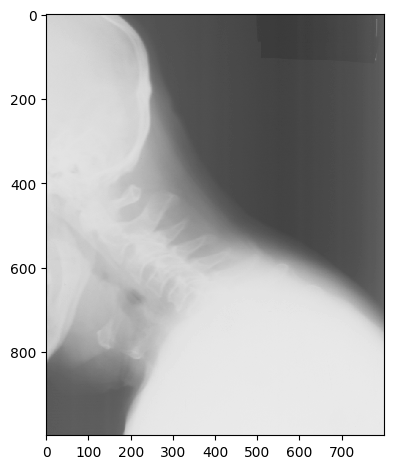

/tmp/ipykernel_16735/1163651075.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


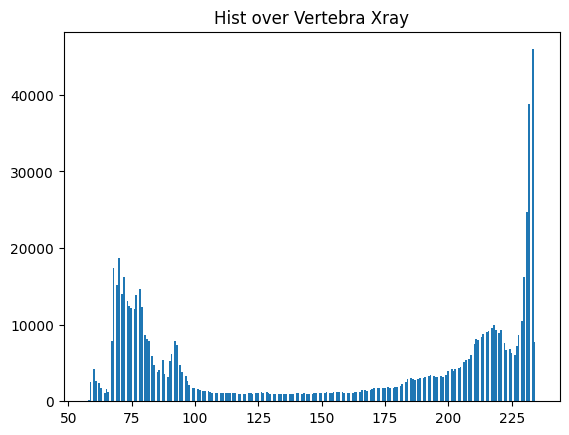

In [ ]:
vertebra_im_path = data_dir + 'vertebra.png'
vertebra_img = io.imread(vertebra_im_path)

# Plot image
io.imshow(vertebra_img)
io.show()
plt.close()

# Plot histogram
plt.hist(vertebra_img.ravel(), bins=256)
plt.title('Hist over Vertebra Xray')
io.show()


Image is quite bimodal, with slight deviances. Segmenting bones from image should be possible.

**Ex 2**: Compute min, max of image

In [12]:
print(f"Min = {vertebra_img.min()}, max = {vertebra_img.max()}")

Min = 57, max = 235


Shows, that the image has potential to increase its contrast, e.g. by stretching the histogram.

### Pixel type conversions

In [ ]:
vert_f_img = img_as_float(vertebra_img)
vert_ub_img = img_as_ubyte(vert_f_img)
print(f"Min, max values of float image = ({vert_f_img.min()}, {vert_f_img.max()})")     # Converts to float range [0,1]
print(f"Min, max values of float image = ({vert_ub_img.min()}, {vert_ub_img.max()})")   # Converts back from float range [0,1] to [0,255]


Min, max values of float image = (0.22352941176470587, 0.9215686274509803)
Min, max values of float image = (57, 235)


### Histogram stretching

**Don't like that we're given the histogram_stretch function from scratch**.

In [14]:
# Function that automatically stretches the histogram of an image
def histogram_stretch(img_in, v_min_d: int = 0, v_max_d: int = 255):
    """
    Stretches the histogram of an image 
    :param img_in: Input image, v_min_d: target min value, v_max_d: target max value
    :return: Image, where the histogram is stretched so the min values is 0 and the maximum value 255
    """
    v_min, v_max = img_in.min(), img_in.max()

    return ((v_max_d - v_min_d) / (v_max - v_min)) * (img_in - v_min) + v_min_d

New min, max: (0.0, 255.0)


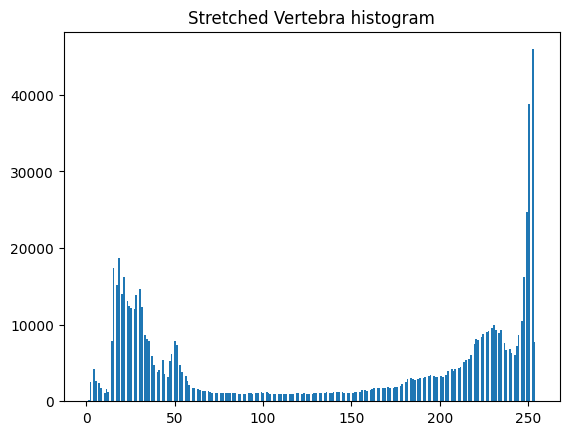

/tmp/ipykernel_16735/2349069453.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(stretched_vertebra, cmap='gray')
/home/ludvikpet/.venv/02503/lib/python3.13/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/tmp/ipykernel_16735/2349069453.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


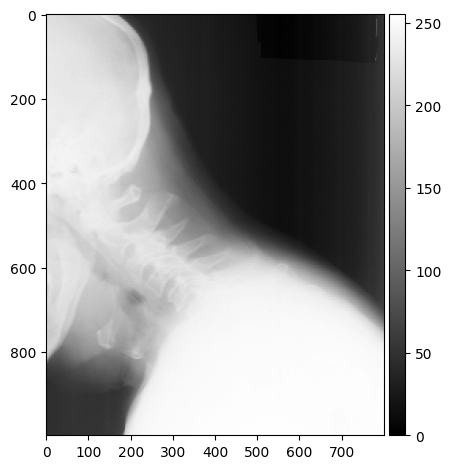

In [18]:
stretched_vertebra = histogram_stretch(vertebra_img)
print(f"New min, max: ({stretched_vertebra.min()}, {stretched_vertebra.max()})")
plt.hist(stretched_vertebra.ravel(), bins=256)
plt.title('Stretched Vertebra histogram')
plt.show()
plt.close()

io.imshow(stretched_vertebra, cmap='gray')
io.show()

Noticably, contrast has increased significantly after stretching. This is especially noticable from the background, that is shifted from values around ~70 to ~20, which increases the focus on the foreground, as less blurring occurs.

### Non-linear pixel value mapping

**Ex 7, 8**: Make- and test gamma function

In [21]:
def gamma_map(img, gamma):
    img_float = img_as_float(img)
    img_gamma = np.pow(img_float, gamma)
    return img_as_ubyte(img_gamma)

# For later ease of use
def plot_image_with_hist(img, title: str = ""): 
    plt.hist(img.ravel(), bins=256)
    if title:
        plt.title('Stretched Vertebra histogram')
    plt.show()
    plt.close()

    io.imshow(img, cmap='gray')
    io.show()

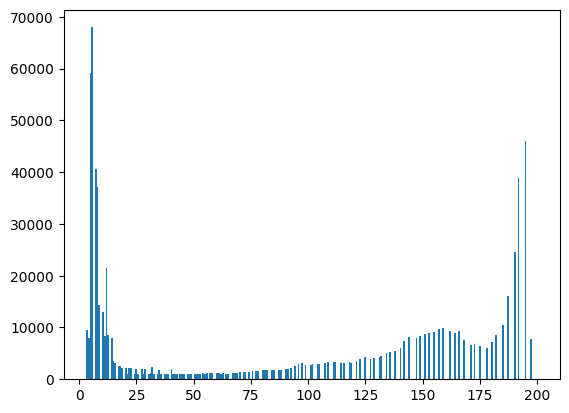

/tmp/ipykernel_16735/469111039.py:14: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img, cmap='gray')
/tmp/ipykernel_16735/469111039.py:15: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


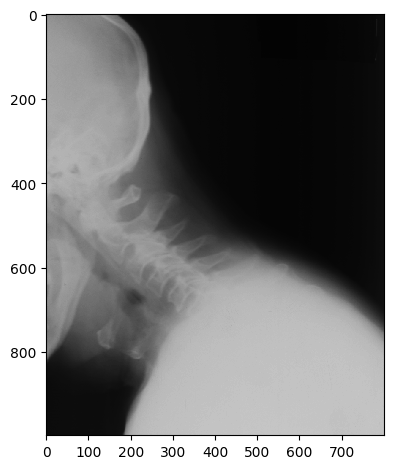

In [32]:
gamma_img = gamma_map(vertebra_img, gamma=3)
plot_image_with_hist(gamma_img)

Noticably, when $\gamma < 1$ image contrast lessens, as darker pixels are highlighted more clearly. Conversely, when setting $\gamma > 1$ contrast increases, as the bright areas are highlighted/brightened up, due to mid areas being decreased. The fact that this works so well is highly dependent on the image. In images with multi-modal histograms, where some modes of objects were contained in the darker end of the spectrum and others in the lighter end, $\gamma$ mapping would be an imperfect choice as either-or is brightened when varying $\gamma$.

### Image segmentation by thresholding

In [38]:
def threshold_image(img, thresh: int = None):
    
    # If thresh is not provided, utilize Otsu's method
    if not thresh:
        thresh = threshold_otsu(img, nbins=256)

    img_bin = (img > thresh)
    img_out = img_as_ubyte(img_bin)
    io.imshow(img_out, cmap = 'gray')
    io.show()

/tmp/ipykernel_16735/234851106.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_out, cmap = 'gray')
/tmp/ipykernel_16735/234851106.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


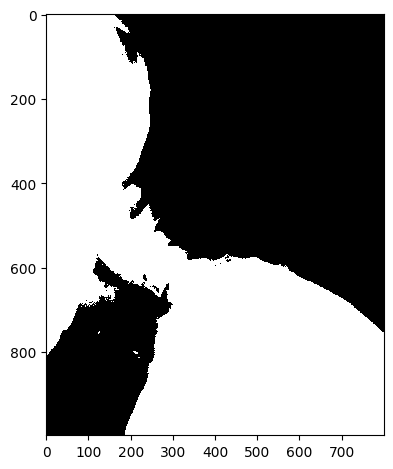

In [36]:
threshold_image(gamma_img, thresh=110)

From testing it can be found, that separating the bones from the background is a difficult task, however, separating the human from the background is much easier. Further testing must be made to separate the bones from the bg, e.g. by using linear combinations of different linear/non-linear mappings (gamma + stretching for example)

### Automatic thresholding using Otsu's method

/tmp/ipykernel_16735/1511497778.py:9: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_out, cmap = 'gray')
/tmp/ipykernel_16735/1511497778.py:10: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


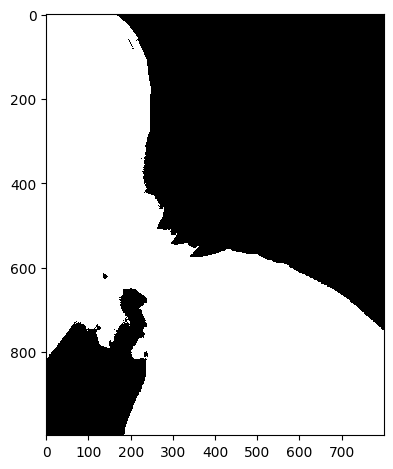

In [39]:
threshold_image(gamma_img)

Similar performance to manual testing, however, nice that this can be done using automatic tooling.

### Color thresholding in RGB color space

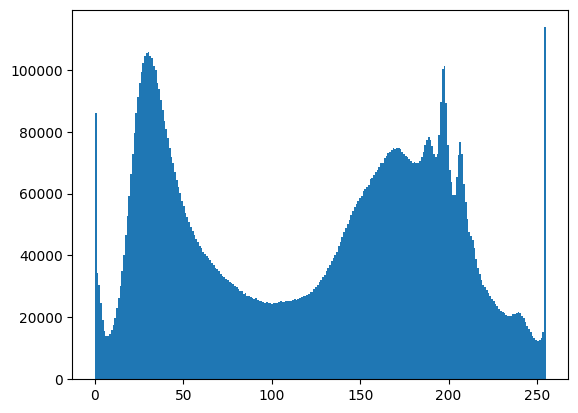

/tmp/ipykernel_16735/1709629885.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_as_ubyte(segment_blue_sign + segment_red_sign), cmap='gray')
/tmp/ipykernel_16735/1709629885.py:14: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


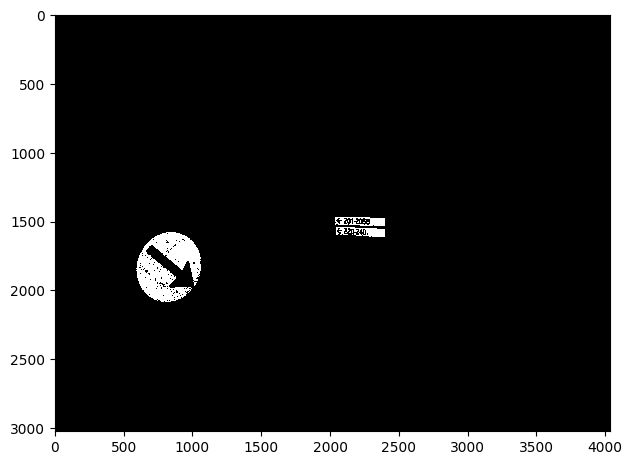

In [50]:
sign_img = io.imread(data_dir + 'DTUSigns2.jpg')
plt.hist(sign_img[:,:,0].ravel(), bins=256)
plt.show()
plt.close()
def detect_dtu_signs(img_in):
    # Filter each color component
    r_img, g_img, b_img = img_in[:,:,0], img_in[:,:,1], img_in[:,:,2]
    segment_blue_sign = (r_img < 10) & (g_img > 85) & (g_img < 105) & \
                    (b_img > 180) & (b_img < 200)
    segment_red_sign = (r_img > 150) & (g_img > 45) & (g_img < 65) & \
                    (b_img > 30) & (b_img < 70)

    io.imshow(img_as_ubyte(segment_blue_sign + segment_red_sign), cmap='gray')
    io.show()
detect_dtu_signs(sign_img)

### HSV (HSI) space thresholding

/tmp/ipykernel_16735/4230901177.py:20: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


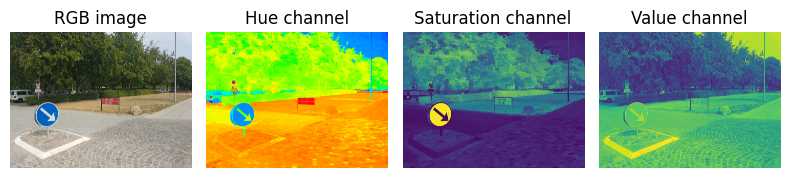

In [ ]:
hsv_img = rgb2hsv(sign_img)
hue_img = hsv_img[:, :, 0]
sat_img = hsv_img[:, :, 1]
value_img = hsv_img[:, :, 2]
fig, (ax0, ax1, ax2, ax3) = plt.subplots(ncols=4, figsize=(8, 2))
ax0.imshow(sign_img)
ax0.set_title("RGB image")
ax0.axis('off')
ax1.imshow(hue_img, cmap='hsv')
ax1.set_title("Hue channel")
ax1.axis('off')
ax2.imshow(sat_img)
ax2.set_title("Saturation channel")
ax2.axis('off')
ax3.imshow(value_img)
ax3.set_title("Value channel")
ax3.axis('off')

fig.tight_layout()
io.show()

/tmp/ipykernel_16735/3341290650.py:7: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


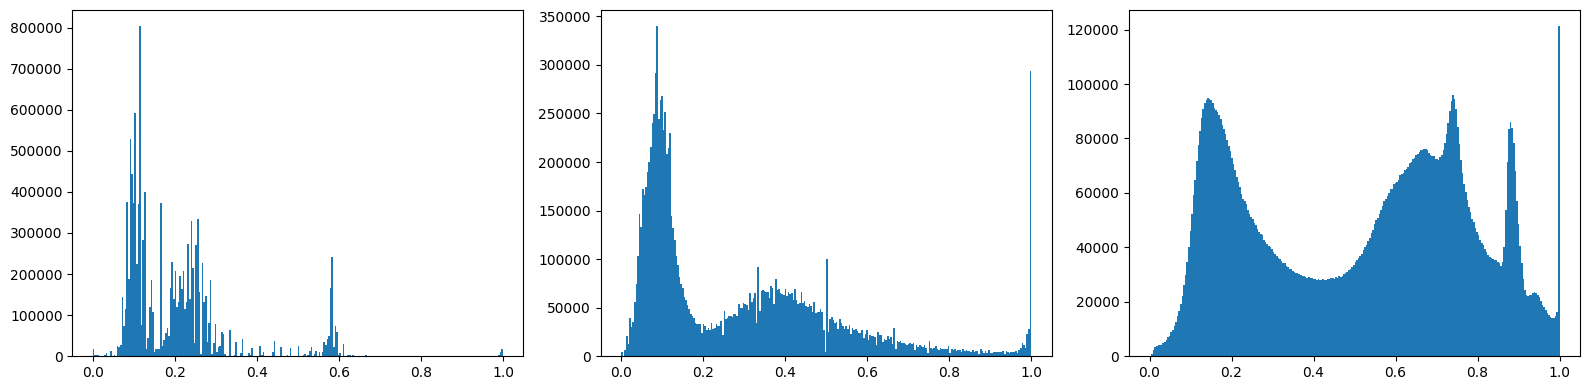

In [53]:
fig, ax = plt.subplots(ncols=3, figsize=(16,4))

ax[0].hist(hue_img.ravel(), bins=256)
ax[1].hist(sat_img.ravel(), bins=256)
ax[2].hist(value_img.ravel(), bins=256)
fig.tight_layout()
io.show()

/tmp/ipykernel_16735/2256059609.py:10: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_as_ubyte(segment_blue_sign + segment_red_sign), cmap='gray')
/tmp/ipykernel_16735/2256059609.py:12: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


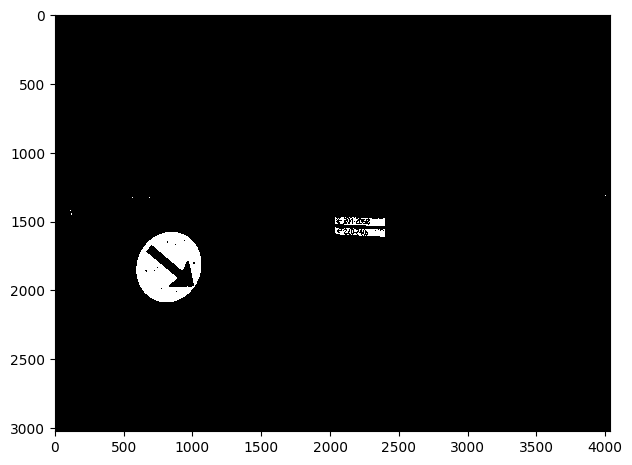

In [67]:

def detect_dtu_signs_HSV(img_in):
    hsv_img = rgb2hsv(img_in)
    hue_img = hsv_img[:, :, 0]
    sat_img = hsv_img[:, :, 1]
    value_img = hsv_img[:, :, 2]

    segment_blue_sign = (sat_img > 0.90) & (value_img > 0.6)
    segment_red_sign = (hue_img > 0.9) & (value_img > 0.5) & (sat_img > 0.6)

    io.imshow(img_as_ubyte(segment_blue_sign + segment_red_sign), cmap='gray')
    # io.imshow(img_as_ubyte(segment_blue_sign), cmap='gray')
    io.show()
detect_dtu_signs_HSV(sign_img)